In [1]:
from src.ColorsAnalysis import *
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
plt.style.use('properties.mplstyle')

In [64]:
savepath = "../results/ColorAnalysis"
create_folder(savepath)

Folder already exists: ../results/ColorAnalysis


## 3D

In [2]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 3

# 1) Ler convertendo "Null" para NaN
df_all_3d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_3d.columns:
        df_all_3d[c] = pd.to_numeric(df_all_3d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_3d = df_all_3d.dropna(subset=["pt_mean","nt_mean"]).copy()

# ver somente um range de colunas
df_clean_3d.loc[:, "L":"nt_erro"]

,L,Nt,k,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro
0,128,200,0.000100,0.00010,1.0,1,300,300,0.448912,0.002645,198.647164,0.398101
1,128,200,0.000100,0.00010,1.0,2,300,300,0.449416,0.002626,198.790695,0.351748
2,128,200,0.000100,0.00010,1.0,3,300,299,0.449224,0.002402,198.873092,0.321302
3,128,200,0.000100,0.00010,1.0,4,300,288,0.442161,0.000561,199.939644,0.051675
4,128,200,0.000100,0.00100,1.0,1,2,2,0.444404,0.001711,199.342293,0.294070
...,...,...,...,...,...,...,...,...,...,...,...,...
1167,512,3500,0.000001,0.22714,1.0,4,100,10,1.000000,0.000000,363.098499,30.542934
1168,512,3500,0.000001,0.22755,1.0,1,100,72,1.000000,0.000000,358.018969,19.676544
1169,512,3500,0.000001,0.22755,1.0,2,100,24,1.000000,0.000000,357.659481,30.900533
1170,512,3500,0.000001,0.22755,1.0,3,100,2,1.000000,0.000000,179.850554,7.734158


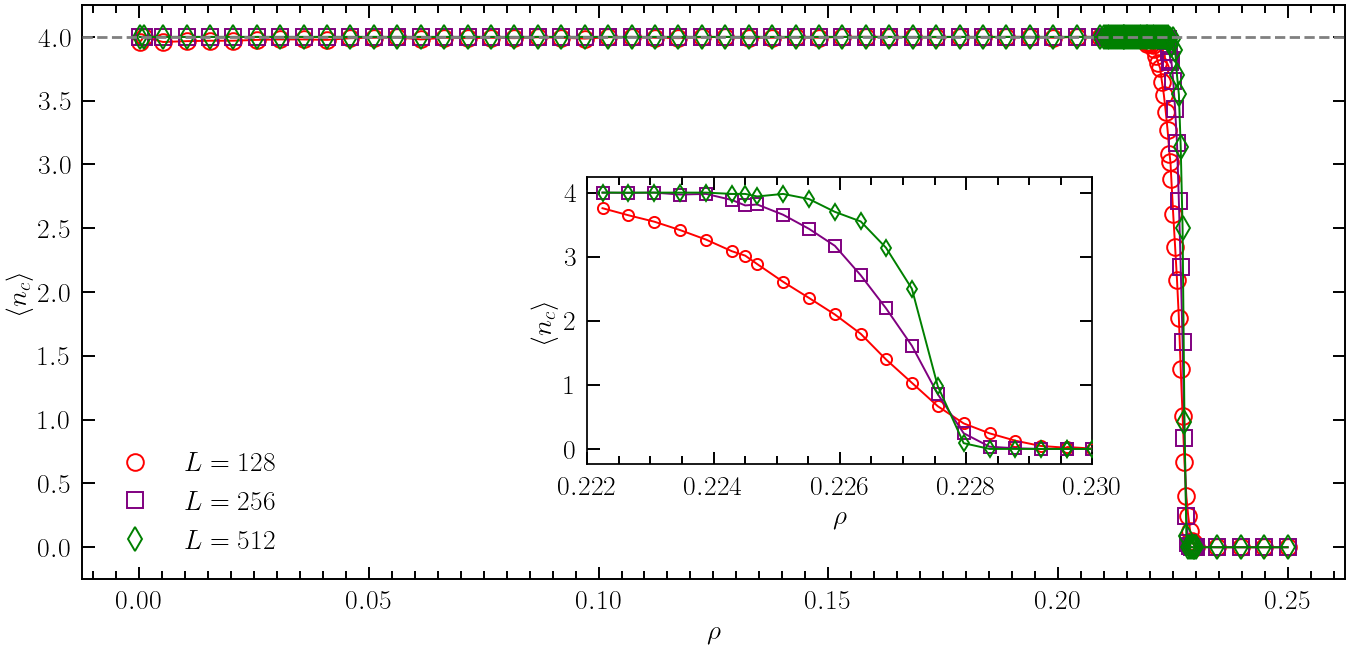

In [3]:
from matplotlib.lines import Line2D
p0_filter = 1.0
L_values = [128, 256, 512]
k_values = [1.0e-04, 1.0e-05, 1.0e-06]

ms = 12
font_tick_size = 20
font_label_size = 20
font_legend_size = 20
colors  = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]   # formatos do PLOT (linha + marcador)
mew = 1.4
thickness = 1.4


# ===== Figura e eixo principais =====
fig, ax = plt.subplots(figsize=(14, 7))

# ticks do eixo principal
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))

datasets = []
legend_handles = []

for idx, (L, kval) in enumerate(zip(L_values, k_values)):
    res = mean_nc_by_rho(df_all_3d, num_colors=4,
                         p0_filter=p0_filter, L_filter=L, k_filter=kval)
    if res.empty:
        continue

    fmt   = markers[idx % len(markers)]   # e.g. "o-"
    color = colors [idx % len(colors)]

    line, = ax.plot(res["rho"], res["nc_mean"], fmt,
                    color=color, linewidth=thickness,
                    ms=ms, markeredgewidth=mew, zorder=2)   # sem label aqui

    # guardar dados para o inset
    datasets.append((res["rho"].to_numpy(),
                     res["nc_mean"].to_numpy(),
                     line.get_marker(), color))

    # --- legenda: proxy só com marcador (sem linha) ---
    legend_handles.append(Line2D(
        [], [], linestyle='None',
        marker=line.get_marker(), markersize=ms,
        markeredgewidth=mew, markerfacecolor='none',
        markeredgecolor=color, color=color, label=fr"$L = {L}$"
    ))

# ----- Inset (zoom) -----
x0, x1 = 0.222, 0.230
inset_x, inset_y, inset_w, inset_h = 0.40, 0.20, 0.40, 0.50  # posição/tamanho (0–1)
axins = ax.inset_axes([inset_x, inset_y, inset_w, inset_h], zorder=10)

# sem grid no inset
axins.set_facecolor("white")
axins.grid(False)

ys_zoom = []
for (x, y, marker, color) in datasets:
    m = (x >= x0) & (x <= x1)
    if np.any(m):
        axins.plot(x[m], y[m], linestyle='-',
                   marker=marker, color=color,
                   linewidth=thickness, ms=max(6, int(ms*0.7)),
                   markeredgewidth=mew, markerfacecolor='none', zorder=11)
        ys_zoom.append(y[m])

axins.set_xlim(x0, x1)
if ys_zoom:
    y_all = np.concatenate(ys_zoom)
    pad = 0.06 * (y_all.ptp() if y_all.ptp() > 0 else 1.0)
    axins.set_ylim(y_all.min() - pad, y_all.max() + pad)

# ticks do inset: major 0.002 e MINOR fixo 0.0001
axins.xaxis.set_major_locator(MultipleLocator(0.002))
axins.xaxis.set_minor_locator(MultipleLocator(0.0005))  # <- aqui é que fixa 1e-4
axins.yaxis.set_major_locator(MultipleLocator(1.0))
# axins.yaxis.set_minor_locator(MultipleLocator(0.5))  # se quiser no y também

axins.tick_params(axis='both', which='major',
                  labelsize=int(font_tick_size), length=9, width=thickness)
axins.tick_params(axis='both', which='minor',
                  length=6, width=thickness)
axins.set_xlabel(r"$\rho$")
axins.set_ylabel(r"$\langle n_c \rangle $")

# estética do inset
for s in axins.spines.values():
    s.set_linewidth(thickness*0.9)

# ----- eixo principal -----
ax.axhline(y=4, color='gray', linestyle='--', lw=2.0, zorder=100)
ax.set_xlabel(r"$\rho$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, 4.25])
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)

# legenda usando os proxies (marcadores apenas)
ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower left", frameon=False)

plt.tight_layout()
#plt.savefig(savepath + "/n_c_versus_rho.pdf", dpi=300)
plt.show()


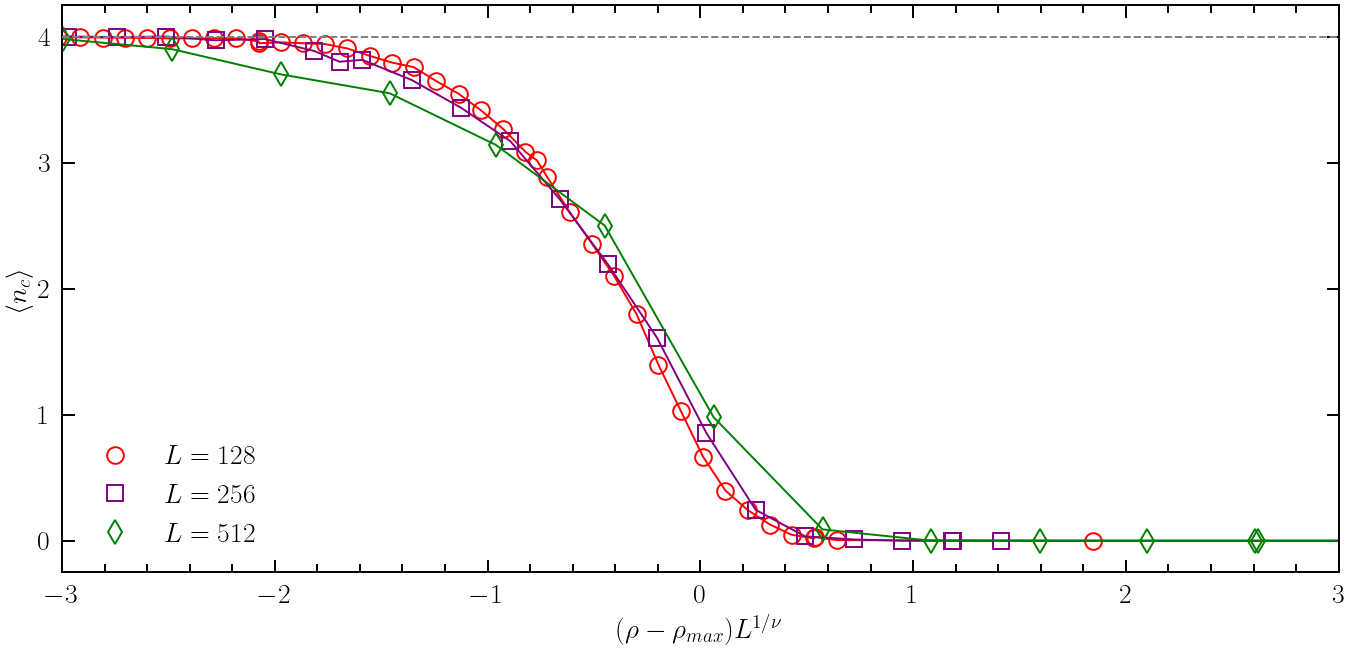

In [4]:
p0_filter = 1.0
L_values = [128, 256, 512]
k_values = [1.0e-04, 1.0e-05, 1.0e-06]

ms = 12
font_tick_size = 20
font_label_size = 20
font_legend_size = 20
colors  = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]   # formatos do PLOT (linha + marcador)
mew = 1.4
thickness = 1.4

assert len(L_values) == len(k_values), "L_values e k_values devem ter o mesmo tamanho."

fig, ax = plt.subplots(figsize=(14,7))
legend_handles = []

for idx, (L, kval) in enumerate(zip(L_values, k_values)):
    res = mean_nc_by_rho(df_all_3d, num_colors=4,
                         p0_filter=p0_filter, L_filter=L, k_filter=kval)
    if res.empty:
        print(f"[WARN] sem dados para L={L}, k={kval}")
        continue

    fmt   = markers[idx % len(markers)]
    color = colors [idx % len(colors)]

    # --- PLOT (não altera marcador: fica EXATAMENTE como você definiu) ---
    line, = ax.plot((res["rho"]-0.2275)*L**(1/0.875), res["nc_mean"], fmt,
                    color=color, linewidth=thickness,
                    ms=ms, markeredgewidth=mew, zorder=2)

    # --- HANDLE da LEGENDA copiando PROPRIEDADES do plot (sem mudanças) ---
    handle = Line2D(
        [0], [0],
        linestyle='None',
        marker=line.get_marker(),
        markersize=ms,
        markeredgewidth=line.get_markeredgewidth(),
        markeredgecolor=line.get_markeredgecolor(),
        markerfacecolor=line.get_markerfacecolor(),      # pode ser 'none' — mantemos
        fillstyle=line.get_fillstyle(),
        alpha=(line.get_alpha() if line.get_alpha() is not None else 1.0),
        color=line.get_color(),
        label=fr"$L = {L}$",
    )
    legend_handles.append(handle)

# Linha guia por cima e limites
#ax.set_xlim(0.0, 0.25)
ax.set_xlim([-3, 3])
ax.axhline(y=4, xmin=0.0, xmax=1.0, color='gray', linestyle='--', lw=1.4, zorder=100)

# Rótulos e limites
ax.set_xlabel(r"$(\rho - \rho_{max})L^{1/\nu}$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, 4.25])

# Ticks
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_major_locator(MultipleLocator(1.0))
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)

# Borda (spines) mais espessa
for spine in ax.spines.values():
    spine.set_linewidth(thickness)

# Legenda com os handles customizados (marcador idêntico ao do plot)
ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower left")

plt.tight_layout()
#plt.savefig(savepath + "/n_rescaling.pdf", dpi=300)
plt.show()


## 2D